In [4]:
import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [3]:
df = pd.read_csv('Student Survey_anonymized - Student Survey_anonymized.csv')

NameError: name 'pd' is not defined

In [158]:
df.columns = df.columns.map(lambda x: x.strip() if isinstance(x, str) else x)

In [159]:
map_dict = {
    'not at all important': 1,
    'not important': 1,
    'slightly important': 2,
    'moderately important': 3,
    'very important': 4,
    'extremely important': 5,
}
def plot_likert(df, cols, pretty, title):
    cols = [c for c in cols if c in df.columns]
    if not cols:
        print("No matching columns.")
        return
    
    # CREATE A COPY - don't modify original!
    df_work = df[cols].copy()
    
    # recode on the COPY
    for c in cols:
        df_work[c] = df_work[c].astype('string').str.strip().str.lower()
        df_work[c + '_num'] = df_work[c].map(map_dict)
    
    num_cols = [f"{c}_num" for c in cols]
    means = df_work[num_cols].mean(skipna=True)
    
    # apply pretty labels
    means.index = [pretty.get(s[:-4], s[:-4]) for s in means.index]  # drop '_num'
    means = means.sort_values(ascending=True)
    
    # plot
    plt.figure(figsize=(8, 4.5))
    plt.barh(means.index, means.values)
    plt.xlabel('Mean importance (1–5)')
    plt.title(title)
    plt.xlim(1, 5)
    plt.tight_layout()
    plt.show()
    
    return means

df['Q2.2_1'].value_counts(dropna=False)

Q2.2_1
Extremely important                                                                                                                                       123
Very important                                                                                                                                             58
Moderately Important                                                                                                                                       24
NaN                                                                                                                                                         7
Slightly important                                                                                                                                          6
Not at all important                                                                                                                                        2
How important are the following aspects for p

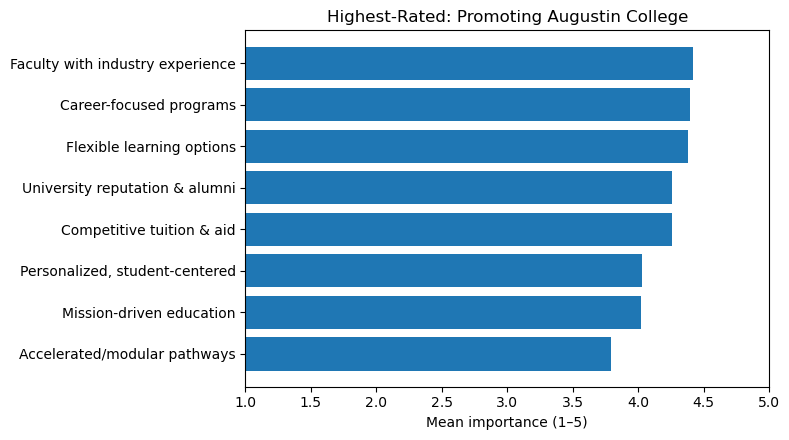

In [194]:

cols = ['Q2.2_1','Q2.2_2','Q2.2_3','Q2.2_4','Q2.2_5','Q2.2_6','Q2.2_7','Q2.2_8']
cols = [c for i, c in enumerate(cols) if c in df.columns and c not in cols[:i]]

map_dict = {
    'not at all important': 1,
    'not important': 1,
    'slightly important': 2,
    'moderately important': 3,
    'very important': 4,
    'extremely important': 5,
}
pretty = {
    'Q2.2_1': 'Flexible learning options',
    'Q2.2_2': 'Career-focused programs',
    'Q2.2_3': 'Competitive tuition & aid',
    'Q2.2_4': 'Mission-driven education',
    'Q2.2_5': 'Personalized, student-centered',
    'Q2.2_6': 'Accelerated/modular pathways',
    'Q2.2_7': 'University reputation & alumni',
    'Q2.2_8': 'Faculty with industry experience'
}
plot_likert(df, cols, pretty, 'Highest-Rated: Promoting Augustin College')

def compare_likert_by_group(df, cols, pretty, map_dict, group_col, title_prefix):
    """Compare mean Likert scores across demographic groups"""
    
    df_work = df[cols + [group_col]].copy()
    
    for c in cols:
        df_work[c] = df_work[c].astype('string').str.strip().str.lower()
        df_work[c + '_num'] = df_work[c].map(map_dict)
    
    num_cols = [f"{c}_num" for c in cols]
    
    results = []
    for group_val in df_work[group_col].dropna().unique():
        group_data = df_work[df_work[group_col] == group_val]
        means = group_data[num_cols].mean(skipna=True)
        means.name = group_val
        results.append(means)
    
    comparison_df = pd.concat(results, axis=1).T
    comparison_df.columns = [pretty.get(c[:-4], c[:-4]) for c in comparison_df.columns]
    
    comparison_df.T.plot(kind='barh', figsize=(10, 6))
    plt.xlabel('Mean importance (1-5)')
    plt.title(f'{title_prefix}')
    plt.legend(title=group_col, bbox_to_anchor=(1.05, 1))
    plt.xlim(1, 5)
    plt.tight_layout()
    plt.show()
    
    return comparison_df.round(2)

In [2]:
df_filtered = df[df['Q1.3'].isin(['Male', 'Female'])].copy()
gender_comparison = compare_likert_by_group(
    df_filtered, cols, pretty, map_dict, 
    'Q1.3',  
    'Highest-Rated: Promoting Augustin College by gender'
)
display(gender_comparison)

df_filtered = df[df['Q1.6'].isin(['White', 'Hispanic or Latino', 'Asian', 'Black or African American'])].copy()
Race_comparison = compare_likert_by_group(
    df_filtered, cols, pretty, map_dict, 
    'Q1.6',  
    'Highest-Rated: Promoting Augustin College by Race'
)
display(Race_comparison)

df_filtered = df[df['Q1.18'].isin(['Online', 'Hybrid (combination of in-person and online courses)', 'In-person'])].copy()
Online_comparison = compare_likert_by_group(
    df_filtered, cols, pretty, map_dict, 
    'Q1.18',  
    'Highest-Rated: Promoting Augustin College by online status'
)
display(Online_comparison)

NameError: name 'df' is not defined

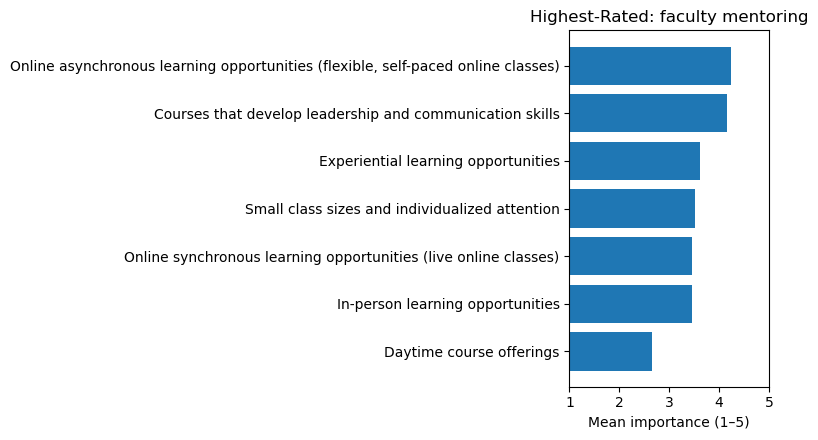

Daytime course offerings                                                            2.658416
In-person learning opportunities                                                    3.455882
Online synchronous learning opportunities (live online classes)                     3.465686
Small class sizes and individualized attention                                      3.519608
Experiential learning opportunities                                                 3.622549
Courses that develop leadership and communication skills                            4.162562
Online asynchronous learning opportunities (flexible, self-paced online classes)    4.230392
dtype: float64

In [164]:
cols = ['Q3.2_1','Q3.2_2','Q3.2_3','Q3.2_4','Q3.2_5','Q3.2_6', 'Q3.2_7']
cols = [c for i, c in enumerate(cols) if c in df.columns and c not in cols[:i]]

pretty = {
    'Q3.2_1': 'Small class sizes and individualized attention',
    'Q3.2_2': 'Experiential learning opportunities',
    'Q3.2_3': 'Courses that develop leadership and communication skills',
    'Q3.2_4': 'In-person learning opportunities',
    'Q3.2_5': 'Daytime course offerings',
    'Q3.2_6': 'Online synchronous learning opportunities (live online classes)',
    'Q3.2_7': 'Online asynchronous learning opportunities (flexible, self-paced online classes)'
}

plot_likert(df, cols, pretty, 'Highest-Rated: faculty mentoring')

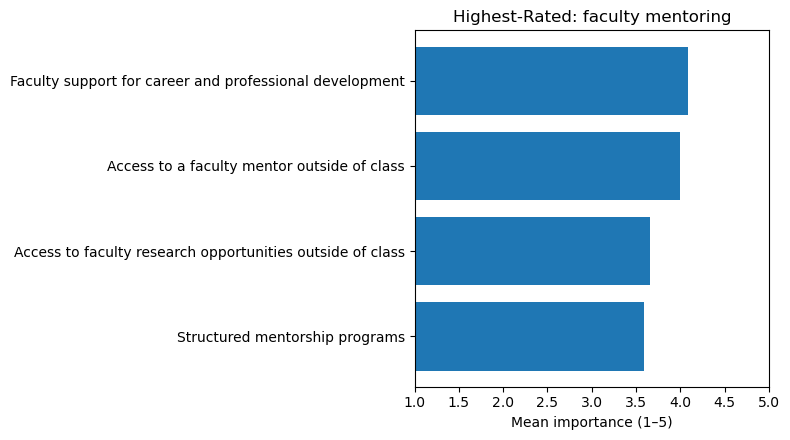

Structured mentorship programs                               3.586207
Access to faculty research opportunities outside of class    3.661765
Access to a faculty mentor outside of class                  3.995098
Faculty support for career and professional development      4.088235
dtype: float64

In [195]:
cols = ['Q3.3_1','Q3.3_2','Q3.3_3','Q3.3_4']
cols = [c for i, c in enumerate(cols) if c in df.columns and c not in cols[:i]]

pretty = {
    'Q3.3_1': 'Access to a faculty mentor outside of class',
    'Q3.3_2': 'Structured mentorship programs',
    'Q3.3_3': 'Faculty support for career and professional development',
    'Q3.3_4': 'Access to faculty research opportunities outside of class'
}

plot_likert(df, cols, pretty, 'Highest-Rated: faculty mentoring')

In [1]:
df_filtered = df[df['Q1.3'].isin(['Male', 'Female'])].copy()
gender_comparison = compare_likert_by_group(
    df_filtered, cols, pretty, map_dict, 
    'Q1.3',  
    'Highest-Rated: faculty mentoring'
)
display(gender_comparison)

df_filtered = df[df['Q1.6'].isin(['White', 'Hispanic or Latino', 'Asian', 'Black or African American'])].copy()
Race_comparison = compare_likert_by_group(
    df_filtered, cols, pretty, map_dict, 
    'Q1.6',  
    'Highest-Rated: faculty mentoring'
)
display(Race_comparison)

df_filtered = df[df['Q1.18'].isin(['Online', 'Hybrid (combination of in-person and online courses)', 'In-person'])].copy()
Online_comparison = compare_likert_by_group(
    df_filtered, cols, pretty, map_dict, 
    'Q1.18',  
    'Highest-Rated: faculty mentoring'
)
display(Online_comparison)

NameError: name 'df' is not defined

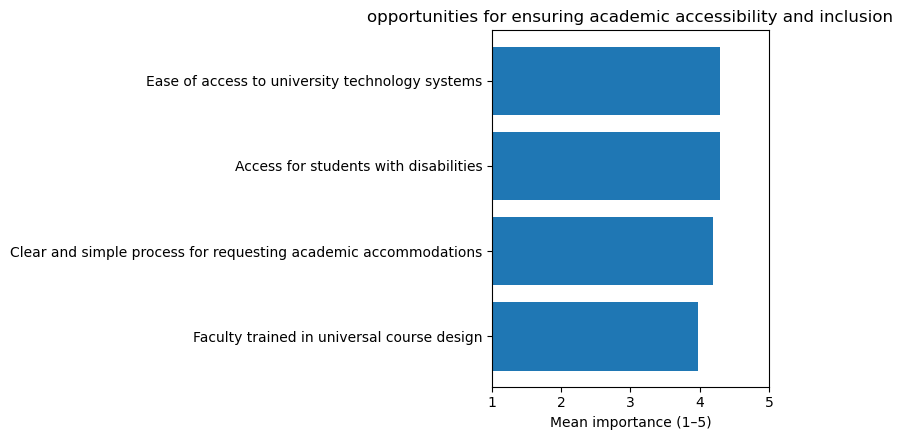

Faculty trained in universal course design                         3.979592
Clear and simple process for requesting academic accommodations    4.186869
Access for students with disabilities                              4.299492
Ease of access to university technology systems                    4.300000
dtype: float64

In [165]:
cols = ['Q3.4_1','Q3.4_2','Q3.4_3','Q3.4_4']
cols = [c for i, c in enumerate(cols) if c in df.columns and c not in cols[:i]]

map_dict = {
    'not important': 1, 'slightly important': 2, 'moderately important': 3,
    'very important': 4, 'extremely important': 5
}
for c in cols:
    df[c] = df[c].astype('string').str.strip().str.lower()
    df[c + '_num'] = df[c].map(map_dict)

pretty = {
    'Q3.4_1': 'Access for students with disabilities',
    'Q3.4_2': 'Faculty trained in universal course design',
    'Q3.4_3': 'Clear and simple process for requesting academic accommodations',
    'Q3.4_4': 'Ease of access to university technology systems'
}

plot_likert(df, cols, pretty, 'opportunities for ensuring academic accessibility and inclusion')

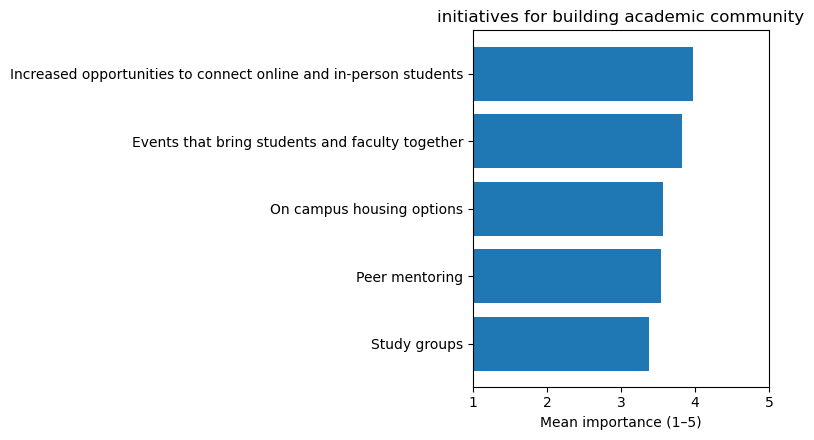

Study groups                                                        3.374332
Peer mentoring                                                      3.543011
On campus housing options                                           3.573333
Events that bring students and faculty together                     3.819588
Increased opportunities to connect online and in-person students    3.969388
dtype: float64

In [166]:
cols = ['Q3.5_1','Q3.5_2','Q3.5_3','Q3.5_4', 'Q3.5_5']
cols = [c for i, c in enumerate(cols) if c in df.columns and c not in cols[:i]]

for c in cols:
    df[c] = df[c].astype('string').str.strip().str.lower()
    df[c + '_num'] = df[c].map(map_dict)

pretty = {
    'Q3.5_1': 'Events that bring students and faculty together',
    'Q3.5_2': 'Peer mentoring',
    'Q3.5_3': 'Study groups',
    'Q3.5_4': 'Increased opportunities to connect online and in-person students',
    'Q3.5_5': 'On campus housing options'
}

plot_likert(df, cols, pretty, 'initiatives for building academic community')

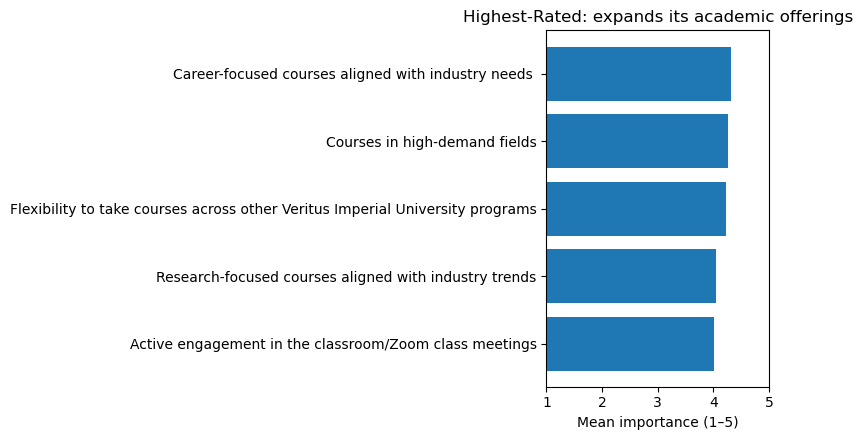

Active engagement in the classroom/Zoom class meetings                           4.010363
Research-focused courses aligned with industry trends                            4.044776
Flexibility to take courses across other Veritus Imperial University programs    4.226131
Courses in high-demand fields                                                    4.270936
Career-focused courses aligned with industry needs                               4.313433
dtype: float64

In [167]:
cols = ['Q3.6_1','Q3.6_2','Q3.6_3','Q3.6_4', 'Q3.6_5']
cols = [c for i, c in enumerate(cols) if c in df.columns and c not in cols[:i]]

for c in cols:
    df[c] = df[c].astype('string').str.strip().str.lower()
    df[c + '_num'] = df[c].map(map_dict)

pretty = {
    'Q3.6_1': 'Career-focused courses aligned with industry needs ',
    'Q3.6_2': 'Research-focused courses aligned with industry trends',
    'Q3.6_3': 'Courses in high-demand fields',
    'Q3.6_4': 'Flexibility to take courses across other Veritus Imperial University programs',
    'Q3.6_5': 'Active engagement in the classroom/Zoom class meetings'
}

plot_likert(df, cols, pretty, 'Highest-Rated: expands its academic offerings')

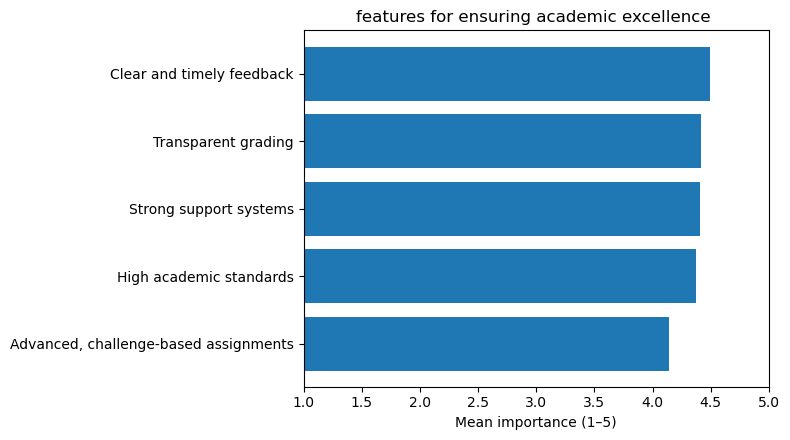

Advanced, challenge-based assignments    4.137931
High academic standards                  4.375610
Strong support systems                   4.403941
Transparent grading                      4.411765
Clear and timely feedback                4.490196
dtype: float64

In [100]:
cols = ['Q3.7_1','Q3.7_2','Q3.7_3','Q3.7_4', 'Q3.7_5']
cols = [c for i, c in enumerate(cols) if c in df.columns and c not in cols[:i]]

for c in cols:
    df[c] = df[c].astype('string').str.strip().str.lower()
    df[c + '_num'] = df[c].map(map_dict)

pretty = {
    'Q3.7_1': 'High academic standards',
    'Q3.7_2': 'Strong support systems',
    'Q3.7_3': 'Advanced, challenge-based assignments',
    'Q3.7_4': 'Transparent grading',
    'Q3.7_5': 'Clear and timely feedback'
}

plot_likert(df, cols, pretty, 'features for ensuring academic excellence ')

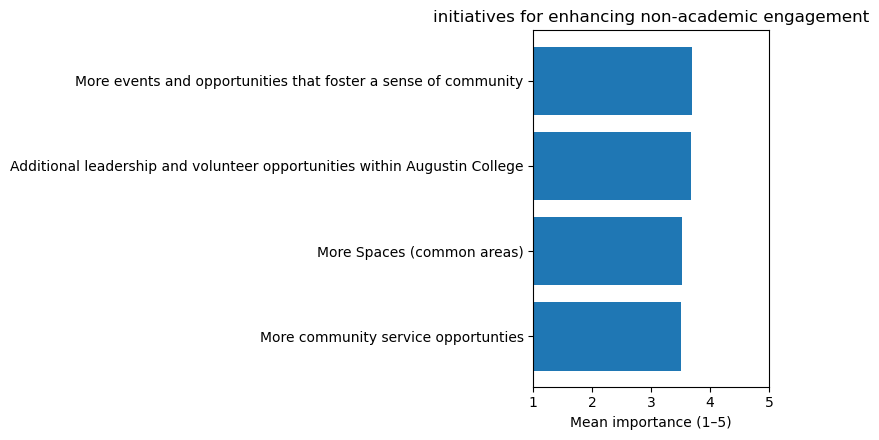

More community service opportunties                                          3.510989
More Spaces (common areas)                                                   3.522727
Additional leadership and volunteer opportunities within Augustin College    3.671958
More events and opportunities that foster a sense of community               3.686170
dtype: float64

In [168]:
cols = ['Q4.2_1','Q4.2_2','Q4.2_3','Q4.2_4']
cols = [c for i, c in enumerate(cols) if c in df.columns and c not in cols[:i]]

for c in cols:
    df[c] = df[c].astype('string').str.strip().str.lower()
    df[c + '_num'] = df[c].map(map_dict)

pretty = {
    'Q4.2_1': 'More events and opportunities that foster a sense of community',
    'Q4.2_2': 'Additional leadership and volunteer opportunities within Augustin College',
    'Q4.2_3': 'More Spaces (common areas)',
    'Q4.2_4': 'More community service opportunties'
}

plot_likert(df, cols, pretty, 'initiatives for enhancing non-academic engagement')

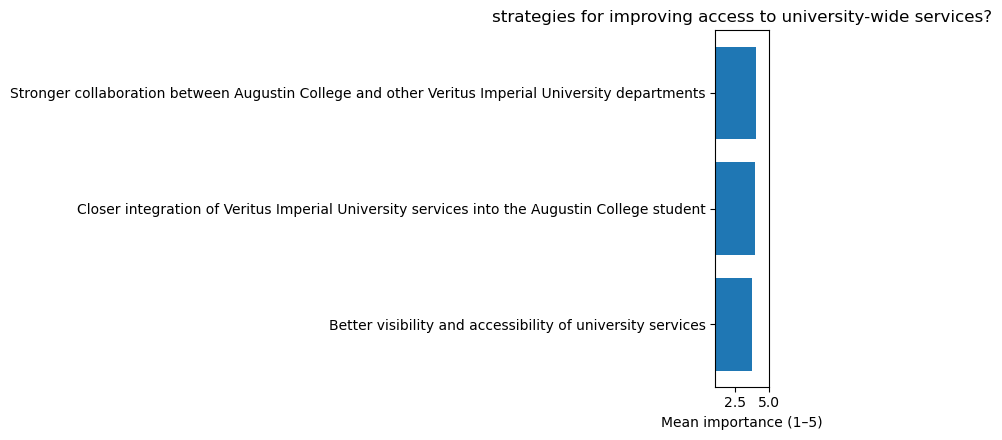

Better visibility and accessibility of university services                                           3.763158
Closer integration of Veritus Imperial University services into the Augustin College student         3.931579
Stronger collaboration between Augustin College and other Veritus Imperial University departments    4.067708
dtype: float64

In [169]:
cols = ['Q4.3_1','Q4.3_2','Q4.3_3']
cols = [c for i, c in enumerate(cols) if c in df.columns and c not in cols[:i]]

for c in cols:
    df[c] = df[c].astype('string').str.strip().str.lower()
    df[c + '_num'] = df[c].map(map_dict)

pretty = {
    'Q4.3_1': 'Better visibility and accessibility of university services',
    'Q4.3_2': 'Closer integration of Veritus Imperial University services into the Augustin College student',
    'Q4.3_3': 'Stronger collaboration between Augustin College and other Veritus Imperial University departments'
}
plot_likert(df, cols, pretty, 'strategies for improving access to university-wide services?')

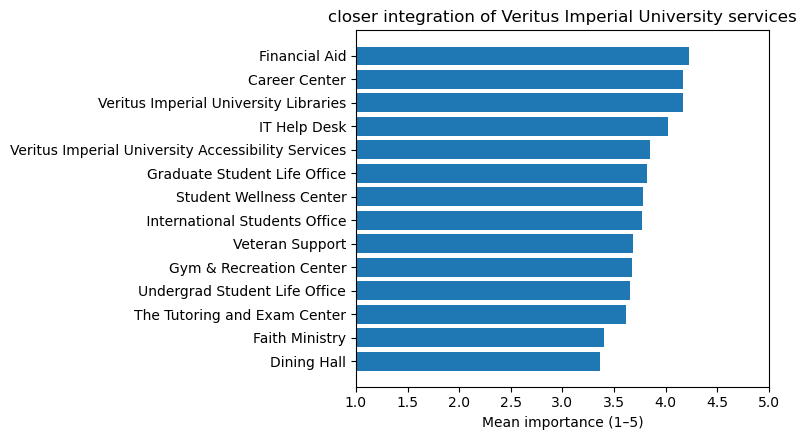

Dining Hall                                           3.363636
Faith Ministry                                        3.403614
The Tutoring and Exam Center                          3.611111
Undergrad Student Life Office                         3.654321
Gym & Recreation Center                               3.678363
Veteran Support                                       3.683333
 International Students Office                        3.770115
Student Wellness Center                               3.779006
Graduate Student Life Office                          3.815217
Veritus Imperial University Accessibility Services    3.849162
IT Help Desk                                          4.021277
Veritus Imperial University Libraries                 4.168421
Career Center                                         4.172043
Financial Aid                                         4.225275
dtype: float64

In [170]:
cols = ['Q4.4_1','Q4.4_2','Q4.4_3', 'Q4.4_4', 'Q4.4_5', 'Q4.4_6', 'Q4.4_7', 'Q4.4_8', 'Q4.4_9', 'Q4.4_10', 'Q4.4_11', 'Q4.4_12', 'Q4.4_13', 'Q4.4_14']
cols = [c for i, c in enumerate(cols) if c in df.columns and c not in cols[:i]]

for c in cols:
    df[c] = df[c].astype('string').str.strip().str.lower()
    df[c + '_num'] = df[c].map(map_dict)

pretty = {
    'Q4.4_1': 'Faith Ministry',
    'Q4.4_2': 'Career Center',
    'Q4.4_3': 'The Tutoring and Exam Center',
    'Q4.4_4': 'Dining Hall',
    'Q4.4_5': 'Veritus Imperial University Accessibility Services',
    'Q4.4_6': 'Financial Aid',
    'Q4.4_7': 'IT Help Desk',
    'Q4.4_8': 'Veritus Imperial University Libraries',
    'Q4.4_9': 'Gym & Recreation Center',
    'Q4.4_10': 'Veteran Support',
    'Q4.4_11': 'Student Wellness Center',
    'Q4.4_12': 'Undergrad Student Life Office',
    'Q4.4_13': 'Graduate Student Life Office',
    'Q4.4_14': ' International Students Office',
}

plot_likert(df, cols, pretty, 'closer integration of Veritus Imperial University services')


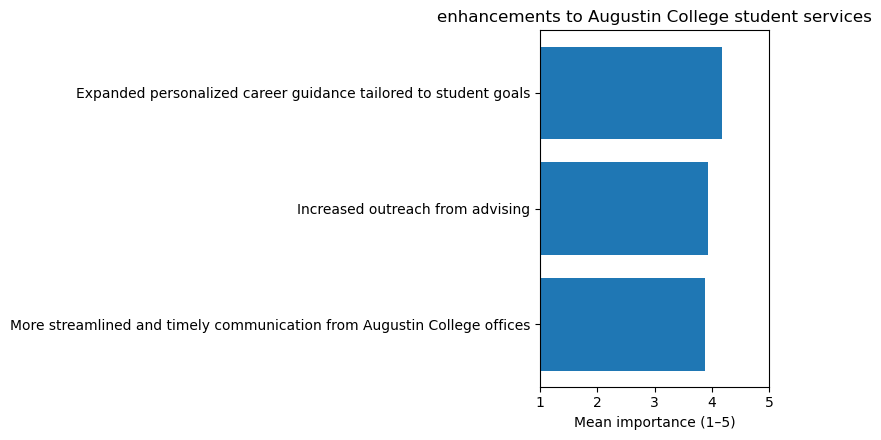

More streamlined and timely communication from Augustin College offices    3.888889
Increased outreach from advising                                           3.941489
Expanded personalized career guidance tailored to student goals            4.180851
dtype: float64

In [171]:
cols = ['Q4.5_1','Q4.5_2','Q4.5_3']
cols = [c for i, c in enumerate(cols) if c in df.columns and c not in cols[:i]]

for c in cols:
    df[c] = df[c].astype('string').str.strip().str.lower()
    df[c + '_num'] = df[c].map(map_dict)

pretty = {
    'Q4.5_1': 'Increased outreach from advising',
    'Q4.5_2': 'More streamlined and timely communication from Augustin College offices',
    'Q4.5_3': 'Expanded personalized career guidance tailored to student goals'
}

plot_likert(df, cols, pretty, 'enhancements to Augustin College student services')

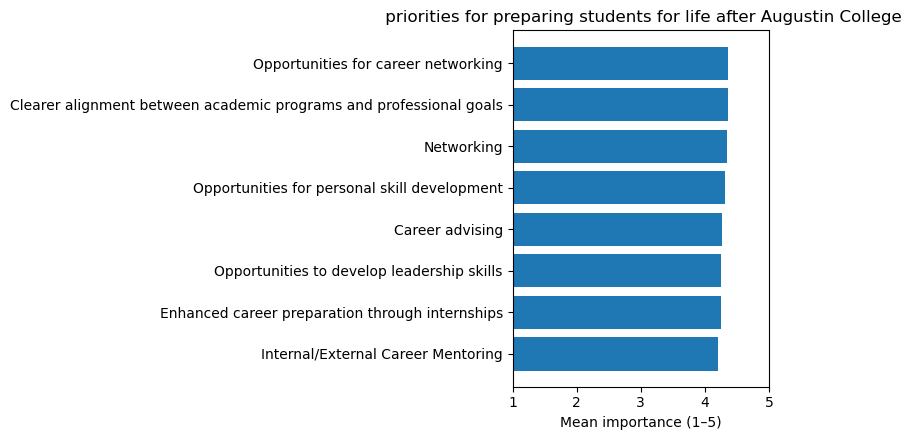

Internal/External Career Mentoring                                    4.197861
Enhanced career preparation through internships                       4.245902
Opportunities to develop leadership skills                            4.246073
Career advising                                                       4.263158
Opportunities for personal skill development                          4.315789
Networking                                                            4.342105
Clearer alignment between academic programs and professional goals    4.356383
Opportunities for career networking                                   4.359788
dtype: float64

In [172]:
cols = ['Q4.6_1','Q4.6_2','Q4.6_3', 'Q4.6_4', 'Q4.6_5', 'Q4.6_6', 'Q4.6_7', 'Q4.6_8']
cols = [c for i, c in enumerate(cols) if c in df.columns and c not in cols[:i]]

for c in cols:
    df[c] = df[c].astype('string').str.strip().str.lower()
    df[c + '_num'] = df[c].map(map_dict)

pretty = {
    'Q4.6_1': 'Opportunities for career networking',
    'Q4.6_2': 'Internal/External Career Mentoring',
    'Q4.6_3': 'Career advising',
    'Q4.6_4': 'Opportunities to develop leadership skills',
    'Q4.6_5': 'Opportunities for personal skill development',
    'Q4.6_6': 'Enhanced career preparation through internships',
    'Q4.6_7': 'Networking',
    'Q4.6_8': 'Clearer alignment between academic programs and professional goals'
}

plot_likert(df, cols, pretty, ' priorities for preparing students for life after Augustin College')

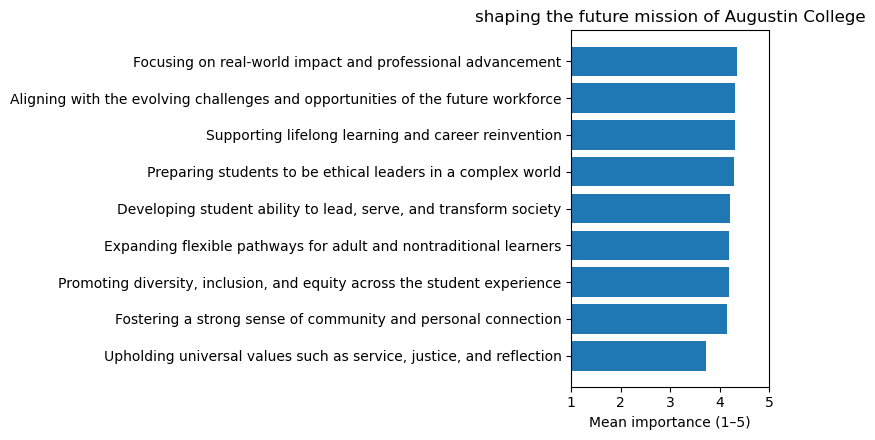

Upholding universal values such as service, justice, and reflection                3.731183
Fostering a strong sense of community and personal connection                      4.147368
Promoting diversity, inclusion, and equity across the student experience           4.198895
Expanding flexible pathways for adult and nontraditional learners                  4.200000
Developing student ability to lead, serve, and transform society                   4.214660
Preparing students to be ethical leaders in a complex world                        4.296296
Supporting lifelong learning and career reinvention                                4.303665
Aligning with the evolving challenges and opportunities of the future workforce    4.308511
Focusing on real-world impact and professional advancement                         4.357895
dtype: float64

In [173]:
cols = ['Q5.2_1','Q5.2_2','Q5.2_3', 'Q5.2_4', 'Q5.2_5', 'Q5.2_6', 'Q5.2_7', 'Q5.2_8', 'Q5.2_9']
cols = [c for i, c in enumerate(cols) if c in df.columns and c not in cols[:i]]

for c in cols:
    df[c] = df[c].astype('string').str.strip().str.lower()
    df[c + '_num'] = df[c].map(map_dict)

pretty = {
    'Q5.2_1': 'Upholding universal values such as service, justice, and reflection',
    'Q5.2_2': 'Expanding flexible pathways for adult and nontraditional learners',
    'Q5.2_3': 'Preparing students to be ethical leaders in a complex world',
    'Q5.2_4': 'Promoting diversity, inclusion, and equity across the student experience',
    'Q5.2_5': 'Focusing on real-world impact and professional advancement',
    'Q5.2_6': 'Supporting lifelong learning and career reinvention',
    'Q5.2_7': 'Fostering a strong sense of community and personal connection',
    'Q5.2_8': 'Developing student ability to lead, serve, and transform society',
    'Q5.2_9': 'Aligning with the evolving challenges and opportunities of the future workforce'
}

plot_likert(df, cols, pretty, 'shaping the future mission of Augustin College')

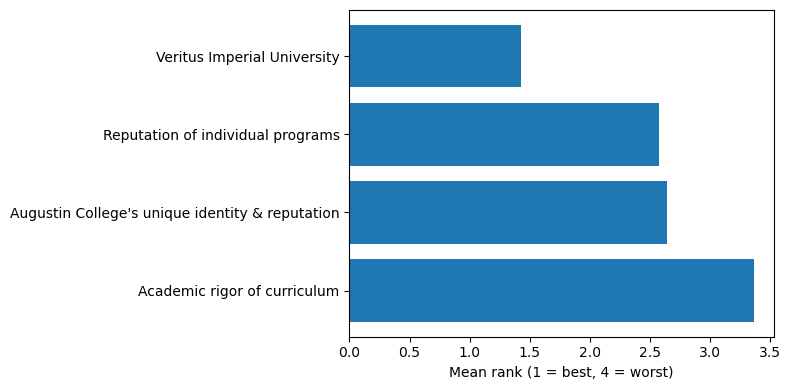

,Mean rank
Veritus Imperial University,1.43
Reputation of individual programs,2.57
Augustin College's unique identity & reputation,2.64
Academic rigor of curriculum,3.36


In [178]:
rank_cols = ['Q2.3_1','Q2.3_2','Q2.3_3','Q2.3_4']
pretty = {
    'Q2.3_1': 'Veritus Imperial University',
    'Q2.3_2': "Augustin College's unique identity & reputation",
    'Q2.3_3': 'Reputation of individual programs',
    'Q2.3_4': 'Academic rigor of curriculum'
}

df[rank_cols] = df[rank_cols].apply(pd.to_numeric, errors='coerce')

mean_rank = df[rank_cols].mean(skipna=True).sort_values()

mean_rank.index = [pretty.get(c, c) for c in mean_rank.index]
mean_rank = mean_rank.round(2)

K = int(np.nanmax(df[rank_cols].to_numpy()))

plt.figure(figsize=(8,4))
plt.barh(mean_rank.index, mean_rank.values)
plt.xlabel(f'Mean rank (1 = best, {K} = worst)')
plt.gca().invert_yaxis()   # best at top
plt.tight_layout()
plt.show()

mean_rank.to_frame('Mean rank')

In [179]:
demo_cols = ['Q1.3','Q1.5','Q1.6','Q1.7', 'Q1.8', 'Q1.9', 'Q1.10', 'Q1.11', 'Q1.12', 'Q1.13', 'Q1.14', 'Q1.15', 'Q1.16', 'Q1.17', 'Q1.18', 'Q1.19']  # <- yours
freqs = {
    col: (df[col].fillna('Missing')
                 .astype('string').str.strip().str.title()
                 .value_counts(dropna=False)
                 .to_frame('n')
                 .assign(**{'%': lambda d: (d['n']/d['n'].sum()*100).round(1)}))
    for col in demo_cols
}

all_freqs = pd.concat(freqs, names=['variable','category'])
all_freqs

all_freqs.to_csv('frequency_table.csv')

all_freqs.to_excel('frequency_table.xlsx')